In [ ]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. Carregar dataset final
# =========================
df = pd.read_csv("df_final.csv")

# =========================
# 2. Separação X e y
# =========================
y = df["price"]
X = df.drop(columns=["price", "date", "id"])

# =========================
# 3. Train / Test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================
# 4. Modelo XGBoost OTIMIZADO
# =========================
model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.1,
    random_state=42,
    n_jobs=-1
)

# =========================
# 5. Validação Cruzada (K-Fold)
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

cv_rmse = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

print("===== CROSS VALIDATION ====")
print("MAE médio:", -cv_mae.mean())
print("RMSE médio:", -cv_rmse.mean())

# =========================
# 6. Treino final
# =========================
model.fit(X_train, y_train)

# =========================
# 7. Avaliação final no teste
# =========================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== TEST SET ====")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

===== CROSS VALIDATION ====
MAE médio: 62602.40039388584
RMSE médio: 117747.06324900012

===== TEST SET ====
MAE: 61029.22381482982
RMSE: 119465.49436109235
R²: 0.89846321304834


In [ ]:
# =========================
# 7. FUTURE UNSEEN
# =========================
future = pd.read_csv("future_unseen_examples.csv")
demo = pd.read_csv("zipcode_demographics.csv")

# Merge igual ao treino
future = future.merge(demo, on="zipcode", how="left")

# Garantir mesmas features do treino
X_future = future[X.columns]

# Predição
future["predicted_price"] = model.predict(X_future)

# Salvar
future.to_csv("future_predictions.csv", index=False)

print("Arquivo salvo: future_predictions.csv")

Arquivo salvo: future_predictions.csv


===== TREINO (price) =====
count    2.159500e+04
mean     5.400932e+05
std      3.670360e+05
min      7.500000e+04
25%      3.220000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

===== FUTURE (predicted_price) =====
count    1.000000e+02
mean     4.917664e+05
std      2.751970e+05
min      1.629989e+05
25%      2.902000e+05
50%      4.321083e+05
75%      6.102637e+05
max      2.017532e+06
Name: predicted_price, dtype: float64


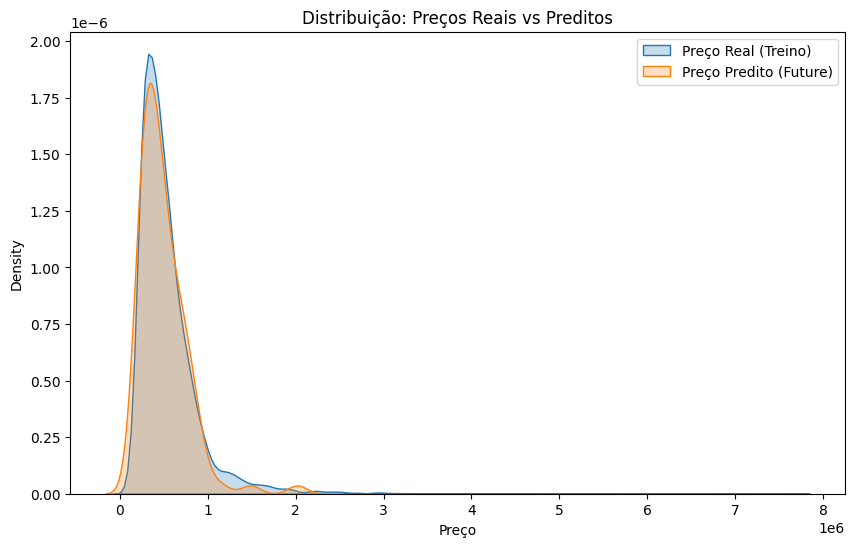

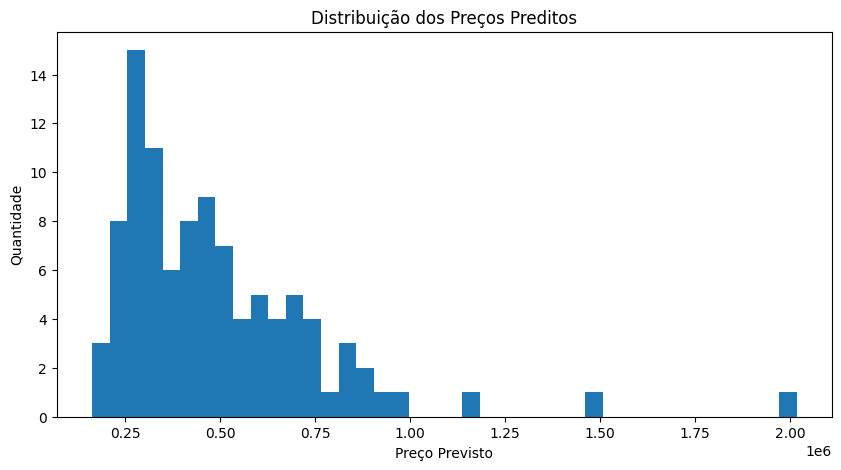


===== PREVISÕES EXTREMAS =====
Quantidade: 3
    predicted_price
8         1485662.0
32        1138300.1
50        2017531.6

===== TOP 10 PREVISÕES MAIS ALTAS =====
    predicted_price
50       2017531.60
8        1485662.00
32       1138300.10
31        959632.30
62        906512.56
94        870002.70
59        861251.56
14        835311.25
41        823023.00
85        812733.20

Preço mínimo previsto: 162998.94
Preço máximo previsto: 2017531.6
Preço médio previsto: 491766.3718


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================
# 1. Carregar dados
# ======================================
train = pd.read_csv("df_final.csv")                  # dataset com preços reais
future = pd.read_csv("future_predictions.csv")       # dataset com predicted_price

# ======================================
# 2. Resumo estatístico
# ======================================
print("===== TREINO (price) =====")
print(train["price"].describe())

print("\n===== FUTURE (predicted_price) =====")
print(future["predicted_price"].describe())

# ======================================
# 3. Comparação visual das distribuições
# ======================================
plt.figure(figsize=(10,6))

sns.kdeplot(train["price"], label="Preço Real (Treino)", fill=True)
sns.kdeplot(future["predicted_price"], label="Preço Predito (Future)", fill=True)

plt.title("Distribuição: Preços Reais vs Preditos")
plt.xlabel("Preço")
plt.legend()
plt.show()

# ======================================
# 4. Histograma das previsões
# ======================================
plt.figure(figsize=(10,5))
plt.hist(future["predicted_price"], bins=40)
plt.title("Distribuição dos Preços Preditos")
plt.xlabel("Preço Previsto")
plt.ylabel("Quantidade")
plt.show()

# ======================================
# 5. Detectar previsões extremas
# ======================================
q1 = future["predicted_price"].quantile(0.25)
q3 = future["predicted_price"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = future[
    (future["predicted_price"] < lower) |
    (future["predicted_price"] > upper)
]

print("\n===== PREVISÕES EXTREMAS =====")
print("Quantidade:", len(outliers))
print(outliers[["predicted_price"]].head(20))

# ======================================
# 6. Top imóveis mais caros previstos
# ======================================
print("\n===== TOP 10 PREVISÕES MAIS ALTAS =====")
print(
    future.sort_values("predicted_price", ascending=False)
    [["predicted_price"]]
    .head(10)
)

# ======================================
# 7. Faixa esperada do modelo
# ======================================
print("\nPreço mínimo previsto:", future["predicted_price"].min())
print("Preço máximo previsto:", future["predicted_price"].max())
print("Preço médio previsto:", future["predicted_price"].mean())